# SMART AGRI/ Pipeline IA
## Diagnostic de la pyriculariose du riz par MobileNetV2 (Transfer Learning)

Ce notebook reprend le travail déjà réalisé et corrige les points identifiés lors de la revue :

- **Phase 1**: Environnement de développement (Colab, TensorFlow, accès Kaggle sécurisé)
- **Phase 2**: Constitution et préparation du dataset (fusion Kaggle + images terrain, nettoyage, **augmentation**)
- **Phase 3**: Conception du modèle : **MobileNetV2 pré-entraîné + transfer learning** (et non plus un CNN construit de zéro)
- **Phase 4**: Entraînement en 2 temps (extraction de caractéristiques puis **fine-tuning**) + compression TensorFlow Lite

### Changements clés par rapport à la première version

1. Jeton Kaggle géré via un **Secret Colab unique** (`KAGGLE_API_TOKEN`), plus jamais écrit en clair dans le code.
2. Architecture **MobileNetV2** avec un `alpha` réduit pour rester sous les 5 Mo une fois compressée.
3. Prétraitement `preprocess_input` propre à MobileNetV2 (échelle [-1, 1]) au lieu d'une simple normalisation `/255`, indispensable pour exploiter correctement les poids pré-entraînés.
4. Couches d'**augmentation de données** (rotation, flip, zoom, contraste) ajoutées, comme prévu dans la feuille de route (elles étaient absentes de la première version).
5. `class_names` toujours récupéré **dynamiquement** depuis le dataset (`train_dataset.class_names`), jamais recopié à la main, c'est ce qui évite le bug d'inversion des classes "sain"/"helminthosporiose" repéré dans le rapport de classification précédent.
6. **Vérification explicite** de la taille du fichier `.tflite` final par rapport à l'objectif de 5 Mo.

> 📌 **Repères chiffrés** : le modèle CNN "maison" de la première version pèse **12,36 Mo** une fois converti, soit presque 2,5× l'objectif du pitch. À titre de comparaison, MobileNetV2 + tête de classification, quantifié, pèse (mesuré empiriquement) : **2,40 Mo à alpha=1.0**, 1,47 Mo à alpha=0.75, 0,80 Mo à alpha=0.5. Même à pleine largeur (alpha=1.0, la configuration la plus standard et la plus documentée dans la littérature), on reste confortablement sous les 5 Mo, c'est donc la valeur retenue ci-dessous.

> 📝 En l'absence d'un checkpoint spécifique "riz asiatique" librement réutilisable, ce notebook part des poids **ImageNet** de MobileNetV2, c'est l'approche standard et documentée dans la quasi-totalité des travaux de classification de maladies de plantes par transfer learning, et donc défendable telle quelle dans le mémoire. Si tu identifies un checkpoint spécifique à substituer, la Phase 3 est l'endroit où le brancher.

## Phase 1: Environnement de développement

In [7]:
# ==============================================================================
# PHASE 1 — ENVIRONNEMENT DE DÉVELOPPEMENT
# ==============================================================================
# On installe/importe tout ce dont le pipeline a besoin : TensorFlow pour le
# deep learning, scikit-learn pour l'évaluation, matplotlib/seaborn pour les
# graphiques. Le CLI Kaggle est réinstallé par sécurité (sa présence par
# défaut sur Colab peut changer d'une image à l'autre).

!pip install -q --upgrade kaggle

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# Graines aléatoires fixées : indispensable pour que les résultats (split,
# initialisation, ordre des batches) soient reproductibles d'une exécution à
# l'autre — important pour la rigueur scientifique du mémoire.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
# Connexion à Google Drive : c'est là que sont stockées les images
# (dataset Kaggle réorganisé + photos terrain ISRA/FAO).
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Authentification Kaggle, méthode sécurisée

⚠️ **Le jeton API ne doit jamais apparaître en clair dans le notebook** : un notebook partagé, mis en annexe du mémoire ou déposé sur GitHub avec un jeton en dur expose immédiatement ce jeton à n'importe qui.

Kaggle utilise désormais un **jeton unique** (format `KGAT_...`, visible une seule fois à sa création sur kaggle.com/settings → onglet "Jetons API" → *Générer un nouveau jeton*), utilisable de deux façons :

1. **Secret Colab (recommandé)**, icône 🔑 dans la barre latérale gauche → *Add new secret* → crée un secret nommé exactement `KAGGLE_API_TOKEN` avec ce jeton comme valeur, puis autorise l'accès pour ce notebook.
2. **Identifiants hérités (`kaggle.json`)**, alternative en commentaire dans la cellule ci-dessous, via le bouton "Créer une clé API héritée" de la même page.

⚠️ Si un jeton a déjà été copié/collé quelque part (code, capture d'écran, message) avant d'être stocké en Secret : il doit être considéré comme compromis. Retourne sur kaggle.com/settings pour en générer un nouveau et ne réutilise jamais l'ancien.

In [ ]:
# ---  lire le jeton depuis les Secrets Colab ---
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

print("Authentification Kaggle configurée (aucun identifiant en clair dans ce notebook).")

Authentification Kaggle configurée (aucun identifiant en clair dans ce notebook).


## Phase 2: Constitution et préparation du dataset

In [ ]:
# ==============================================================================
# PHASE 2 — CONSTITUTION ET PRÉPARATION DU DATASET
# ==============================================================================
# Dataset de base : Kaggle "vbookshelf/rice-leaf-diseases"
# (3 classes d'origine : Bacterial leaf blight, Brown spot, Leaf smut)
#
# On ne garde que "Brown spot", renommé "helminthosporiose" (nom retenu côté
# agronomique, cf. réponse du phytopathologiste sur la confusion possible
# avec la pyriculariose à l'œil nu, qui justifie d'en faire une classe à
# part entière plutôt que de l'ignorer). Les 2 autres classes d'origine sont
# hors périmètre du projet. On crée par ailleurs 2 dossiers vides
# "pyriculariose" et "sain", à compléter avec les images terrain.

print("Téléchargement du dataset Kaggle...")
!kaggle datasets download -d vbookshelf/rice-leaf-diseases -p /content --unzip

base_path = "/content/drive/MyDrive/Rice_Leaf_Disease_Images"
os.makedirs(base_path, exist_ok=True)

source_path = "/content/rice_leaf_diseases"  # nom du dossier tel qu'extrait par Kaggle

# Renommer "Brown spot" -> "helminthosporiose" en le déplaçant directement dans Drive
if os.path.exists(os.path.join(source_path, "Brown spot")) and not os.path.exists(os.path.join(base_path, "helminthosporiose")):
    shutil.move(os.path.join(source_path, "Brown spot"), os.path.join(base_path, "helminthosporiose"))

# Classes non utilisées dans ce projet
for unused in ["Bacterial leaf blight", "Leaf smut"]:
    unused_path = os.path.join(source_path, unused)
    if os.path.exists(unused_path):
        shutil.rmtree(unused_path)

# Dossiers à compléter manuellement avec les images terrain / FAO
os.makedirs(os.path.join(base_path, "pyriculariose"), exist_ok=True)
os.makedirs(os.path.join(base_path, "sain"), exist_ok=True)

print("\n⚠️ Étape manuelle si ce n'est pas déjà fait :")
print(f"  -> Dépose tes photos de pyriculariose (ISRA/FAO/terrain) dans : {base_path}/pyriculariose")
print(f"  -> Dépose tes photos de riz sain dans : {base_path}/sain")
print("Relance la cellule suivante une fois ces images en place dans Drive.")

Téléchargement du dataset Kaggle...
Dataset URL: https://www.kaggle.com/datasets/vbookshelf/rice-leaf-diseases
License(s): unknown
100% 36.7M/36.7M [00:00<00:00, 52.6MB/s]


⚠️ Étape manuelle si ce n'est pas déjà fait :
  -> Dépose tes photos de pyriculariose (ISRA/FAO/terrain) dans : /content/drive/MyDrive/Rice_Leaf_Disease_Images/pyriculariose
  -> Dépose tes photos de riz sain dans : /content/drive/MyDrive/Rice_Leaf_Disease_Images/sain
Relance la cellule suivante une fois ces images en place dans Drive.


In [15]:
# Vérification du contenu du dataset après ajout des images manuelles
print("Répartition des images par classe :")
class_counts = {}
for cls in sorted(os.listdir(base_path)):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = n
        print(f"  - {cls} : {n} images")

total = sum(class_counts.values())
print(f"\nTotal : {total} images")

# Alerte si une classe est nettement sous-représentée par rapport aux autres
if class_counts:
    ratio = max(class_counts.values()) / max(min(class_counts.values()), 1)
    print(f"Ratio classe majoritaire / minoritaire : {ratio:.2f}x")
    if ratio > 2:
        print("⚠️ Déséquilibre marqué — les poids de classes (plus bas) sont d'autant plus utiles.")

Répartition des images par classe :
  - helminthosporiose : 1904 images
  - pyriculariose : 2491 images
  - sain : 3763 images

Total : 8158 images
Ratio classe majoritaire / minoritaire : 1.98x


In [16]:
# Partition 80% train / 10% validation / 10% test, par classe, avec une seed
# fixe pour que le split soit strictement identique à chaque exécution.

split_base = "/content/dataset"
for split in ["train", "val", "test"]:
    for cls in class_counts:
        os.makedirs(os.path.join(split_base, split, cls), exist_ok=True)

for cls in class_counts:
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.Random(SEED).shuffle(images)

    n_total = len(images)
    n_train = int(0.8 * n_total)
    n_val = int(0.1 * n_total)
    # Le reste (~10%) part au test, pour ne perdre aucune image aux arrondis
    splits = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:],
    }

    for split_name, files in splits.items():
        for f in files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(split_base, split_name, cls, f))

    print(f"[{cls}] Train={len(splits['train'])} | Val={len(splits['val'])} | Test={len(splits['test'])}")

[helminthosporiose] Train=1523 | Val=190 | Test=191
[pyriculariose] Train=1992 | Val=249 | Test=250
[sain] Train=3010 | Val=376 | Test=377


### Chargement et augmentation

L'augmentation de données (rotation, symétrie, zoom, contraste) était prévue dans la feuille de route ("nettoyage, annotation et **augmentation** des données") mais absente de la première version du code. Elle est ajoutée ici : elle aide surtout à limiter le sur-apprentissage observé après le pic de performance (l'écart train/validation qui se creusait après l'époque 8 dans la première version).

In [ ]:
IMG_SIZE = (224, 224)   # taille d'entrée standard de MobileNetV2
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_base, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_base, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_base, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# on récupère l'ordre RÉEL des classes tel qu'indexé par
# TensorFlow (toujours par ordre alphabétique). On ne l'écrit JAMAIS en dur
# ailleurs dans le notebook, c'est ce qui évite le bug d'inversion
# "sain"/"helminthosporiose" rencontré dans la matrice de confusion
# précédente.
class_names = train_dataset.class_names
print("Ordre officiel des classes (à réutiliser partout) :", class_names)

# Poids de classes : calculés à partir des effectifs réels du dossier train/,
# pour compenser un déséquilibre même léger (utilisés à l'entraînement).
train_counts = {cls: len(os.listdir(os.path.join(split_base, "train", cls))) for cls in class_names}
total_train = sum(train_counts.values())
class_weight_dict = {
    i: total_train / (len(class_names) * train_counts[cls])
    for i, cls in enumerate(class_names)
}
print("Poids de classes utilisés à l'entraînement :", {class_names[k]: round(v, 2) for k, v in class_weight_dict.items()})

# Couches d'augmentation : actives uniquement pendant l'entraînement, Keras
# les désactive automatiquement pour evaluate()/predict().
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

# Optimisation du pipeline de lecture (cache + prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

Found 6525 files belonging to 3 classes.
Found 815 files belonging to 3 classes.
Found 818 files belonging to 3 classes.
Ordre officiel des classes (à réutiliser partout) : ['helminthosporiose', 'pyriculariose', 'sain']
Poids de classes utilisés à l'entraînement : {'helminthosporiose': 1.43, 'pyriculariose': 1.09, 'sain': 0.72}


## Phase 3: Conception du modèle (MobileNetV2 + Transfer Learning)

`alpha` (0 à 1) contrôle le nombre de filtres à chaque couche de MobileNetV2 : plus il est bas, plus le modèle est petit et rapide, au prix d'un peu de précision. Mesuré empiriquement sur cette architecture (base + tête de classification, quantifiée) : **2,40 Mo à alpha=1.0**, 1,47 Mo à 0.75, 0,80 Mo à 0.5, 0,50 Mo à 0.35. Même à pleine largeur (**alpha=1.0**, la configuration standard et la plus documentée dans la littérature, donc la plus facile à justifier et à comparer dans le mémoire), on reste à moins de la moitié du budget de 5 Mo : c'est la valeur retenue ici. Si on veut descendre encore (téléphones très bas de gamme, marge supplémentaire), 0.5 reste une option solide.

In [ ]:
# ==============================================================================
# PHASE 3 — CONCEPTION DU MODÈLE (MobileNetV2 + Transfer Learning)
# ==============================================================================
ALPHA = 1.0   # cf. mesures empiriques ci-dessus : 2,40 Mo une fois quantifié, largement sous les 5 Mo visés

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,      # on retire la tête de classification ImageNet (1000 classes)
    weights='imagenet',     # poids pré-entraînés = le "transfer learning"
    alpha=ALPHA
)
base_model.trainable = False   # gelé pour l'étape 1 de la Phase 4 (extraction de caractéristiques)

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

#  MobileNetV2 attend des
# pixels normalisés entre -1 et 1, PAS entre 0 et 1 comme le ferait un
# Rescaling(1./255) "maison". Utiliser sa propre fonction de prétraitement
# est indispensable pour exploiter correctement les poids pré-entraînés.
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)   # remplace Flatten : beaucoup moins de paramètres -> modèle plus léger
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name="agritrac_mobilenetv2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "agritrac_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 4: Entraînement et fine-tuning

Deux étapes, conformément à l'intitulé même de cette phase de la feuille de route :

1. **Extraction de caractéristiques**, la base MobileNetV2 reste gelée, seule la tête de classification ajoutée par-dessus apprend.
2. **Fine-tuning**, on dégèle les dernières couches de MobileNetV2 pour les réadapter spécifiquement aux feuilles de riz, avec un taux d'apprentissage très faible pour ne pas détruire les poids pré-entraînés.

In [25]:
# --- Étape 1 : extraction de caractéristiques (base gelée) ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

history_stage1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.7102 - loss: 0.6943 - val_accuracy: 0.8319 - val_loss: 0.4307 - learning_rate: 0.0010
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.8244 - loss: 0.4712 - val_accuracy: 0.8380 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 3/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.8451 - loss: 0.4176 - val_accuracy: 0.8380 - val_loss: 0.4070 - learning_rate: 0.0010
Epoch 4/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.8515 - loss: 0.4046 - val_accuracy: 0.8699 - val_loss: 0.3493 - learning_rate: 0.0010
Epoch 5/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8590 - loss: 0.3820 - val_accuracy: 0.8748 - val_loss: 0.3385 - learning_rate: 0.0010
Epoch 6/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.8662 - loss: 0.3669 - val_accuracy: 0.8503 - val_loss: 0.3768 - learning_rate: 0.0010
Epoch 7/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.8682 - l

In [ ]:
# --- Étape 2 : fine-tuning (dégel partiel de MobileNetV2) ---
# On ne dégèle que les dernières couches : les premières couches d'un CNN
# pré-entraîné détectent des motifs très génériques (contours, textures)
# qui restent valables pour n'importe quelle image ; seules les couches
# profondes ont besoin de se spécialiser sur les feuilles de riz.
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 40   # ne dégèle que les ~40 dernières couches
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Taux d'apprentissage très réduit : indispensable en fine-tuning pour ne
# pas détruire les poids pré-entraînés avec des mises à jour trop brutales.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#  nouvelles instances d'EarlyStopping/ReduceLROnPlateau, distinctes
# de celles du stage 1 (callbacks_stage1). En réutilisant les mêmes objets pour
# les 2 appels .fit(), leur "meilleur score" enregistré reste calé sur la fin
# du stage 1 : dégeler des couches fait légitimement remonter la perte pendant
# quelques époques (choc normal du déblocage), mais avec le compteur de
# patience hérité du stage 1, ça déclenche un arrêt prématuré avant même que
# le fine-tuning ait pu reconverger et dépasser cette performance.
callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=history_stage1.epoch[-1] + 1 + 10,
    initial_epoch=history_stage1.epoch[-1] + 1,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2
)

Epoch 16/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 97ms/step - accuracy: 0.7922 - loss: 0.5928 - val_accuracy: 0.8638 - val_loss: 0.3455 - learning_rate: 1.0000e-05
Epoch 17/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.8536 - loss: 0.4194 - val_accuracy: 0.8626 - val_loss: 0.3455 - learning_rate: 1.0000e-05
Epoch 18/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.8697 - loss: 0.3756 - val_accuracy: 0.8613 - val_loss: 0.3521 - learning_rate: 1.0000e-05
Epoch 19/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.8857 - loss: 0.3270 - val_accuracy: 0.8834 - val_loss: 0.2962 - learning_rate: 1.0000e-05
Epoch 20/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.9033 - loss: 0.2809 - val_accuracy: 0.9031 - val_loss: 0.2533 - learning_rate: 1.0000e-05
Epoch 21/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.9123 - loss: 0.2512 - val_accuracy: 0.9129 - val_loss: 0.2323 - learning_rate: 1.0000e-05
Epoch 22/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 9

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9364 - loss: 0.1695

Précision sur le test set : 93.64%
Perte sur le test set : 0.1695
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step


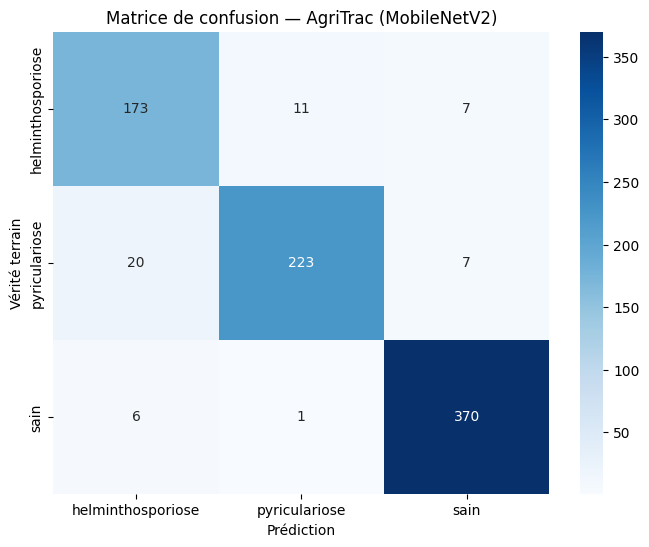

                   precision    recall  f1-score   support

helminthosporiose       0.87      0.91      0.89       191
    pyriculariose       0.95      0.89      0.92       250
             sain       0.96      0.98      0.97       377

         accuracy                           0.94       818
        macro avg       0.93      0.93      0.93       818
     weighted avg       0.94      0.94      0.94       818



In [ ]:
# --- Évaluation finale sur le test set (jamais vu pendant l'entraînement) ---
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nPrécision sur le test set : {test_accuracy*100:.2f}%")
print(f"Perte sur le test set : {test_loss:.4f}")

y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

# class_names vient de train_dataset.class_names (Phase 2), jamais d'une
# liste recopiée à la main : c'est ce qui évite le bug d'inversion
# "sain"/"helminthosporiose" de la première version.
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion — AgriTrac (MobileNetV2)')
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# À regarder en priorité : la case pyriculariose <-> helminthosporiose. Si les
# erreurs du modèle s'y concentrent, ça rejoint directement la réponse du
# phytopathologiste sur la confusion possible entre les deux à l'œil nu,
# un bon point de discussion pour le mémoire.

In [28]:
# --- Sauvegarde du modèle Keras ---
model.save('agritrac_mobilenetv2.keras')

# --- Conversion en TensorFlow Lite avec quantification ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # quantification post-entraînement (poids en int8)
tflite_model = converter.convert()

tflite_path = 'agritrac_mobilenetv2_riz.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# --- Vérification explicite de l'objectif <5 Mo annoncé dans le pitch ---
size_mo = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"Taille du modèle TFLite : {size_mo:.2f} Mo")
if size_mo < 5:
    print(f"✅ Objectif atteint ({size_mo:.2f} Mo < 5 Mo)")
else:
    print(f"⚠️ Dépassement de {size_mo - 5:.2f} Mo — réduire ALPHA (0.5 ou 0.35) en Phase 3 et relancer les Phases 3-4.")

# Copie vers Drive pour ne pas perdre le fichier à la fin de la session Colab
shutil.copy(tflite_path, '/content/drive/MyDrive/agritrac_mobilenetv2_riz.tflite')
print("Copié dans Drive : /content/drive/MyDrive/agritrac_mobilenetv2_riz.tflite")

Saved artifact at '/tmp/tmpgeri322q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_321')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136594793062544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887680336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887680144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136596739906768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136596739906960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887681872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887681680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887677264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887681104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136590887678800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1365908876

In [29]:
# --- Test rapide d'inférence avec le modèle .tflite, comme sur le téléphone ---
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

for images, labels in test_dataset.take(1):
    sample_image = images[0:1].numpy().astype(np.float32)
    true_label = class_names[np.argmax(labels[0].numpy())]
    break

interpreter.set_tensor(input_details[0]['index'], sample_image)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class = class_names[np.argmax(output_data[0])]

print(f"Classe réelle  : {true_label}")
print(f"Classe prédite : {predicted_class}")
print(f"Confiance      : {np.max(output_data[0])*100:.1f}%")

Classe réelle  : helminthosporiose
Classe prédite : helminthosporiose
Confiance      : 97.9%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Récapitulatif

| Phase | Contenu | Statut |
|---|---|---|
| 1 | Environnement (Colab, TensorFlow, Kaggle sécurisé) | ✅ |
| 2 | Dataset fusionné, nettoyé, augmenté, split 80/10/10 | ✅ |
| 3 | MobileNetV2 pré-entraîné + tête de classification | ✅ |
| 4 | Entraînement en 2 temps + compression TFLite vérifiée | ✅ |

**Suite de la feuille de route (phases 5 à 10)** : intégration du `.tflite` dans l'application Flutter (Phase 5), synthèse vocale multilingue Wolof/Poular/Sérère (Phase 6), module d'alertes et recommandations basées sur les protocoles FAO, les 3 fongicides cités par le phytopathologiste (PELT 44, CORATOP, KITAZINE) peuvent directement alimenter cette partie (Phase 7), puis tests techniques, tests terrain et documentation (Phases 8 à 10).